# Midterm Project: Used Car Dataset — Cleanup & Data Preparation

**Dataset:** Used Car Listings (Kaggle)  
**Goal:** Clean raw data and prepare features for a Machine Learning model  
**ML Problem:** Predict the asking price (`AskPrice`) of a used car given its attributes  

---

## Table of Contents
1. [Load & Inspect the Raw Dataset](#1)
2. [Train / Test Split (70/30)](#2)
3. [EDA on Training Data Only](#3)
4. [Data Cleaning Steps (Before → After)](#4)
   - 4a. Parse `kmDriven` (string → numeric)
   - 4b. Parse `AskPrice` (string → numeric)
   - 4c. Handle Missing Values in `kmDriven`
   - 4d. Remove Duplicates
   - 4e. Drop Low-Utility Columns (`AdditionInfo`, `PostedDate`, `Year`)
   - 4f. Filter Rare Brands (keep top brands only)
   - 4g. Encoding: One-Hot Encode Categorical Columns
   - 4h. Scaling: Standardize Numeric Columns (visualization only — CSV saved unscaled)
5. [Before vs After Summary](#5)
6. [Save Cleaned Dataset (real values, Excel-friendly)](#6)
7. [ML Problem Discussion](#7)


## 0. Setup — Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 4)

print('Libraries loaded successfully.')

Libraries loaded successfully.


<a id='1'></a>
## 1. Load & Inspect the Raw Dataset

We load the original CSV exactly as downloaded — **no modifications**.

In [5]:
# Load the raw dataset
df_raw = pd.read_csv('used_car_dataset.csv')

print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(5)

Shape: 9,582 rows × 11 columns


,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,Honda,City,2001,23,"98,000 km",Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"
1,Toyota,Innova,2009,15,190000.0 km,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000"
2,Volkswagen,VentoTest,2010,14,"77,246 km",Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999"
3,Maruti Suzuki,Swift,2017,7,"83,500 km",Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,Baleno,2019,5,"45,000 km",Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"


In [6]:
# Data types and null counts
info_df = pd.DataFrame({
    'dtype':       df_raw.dtypes.astype(str),
    'null_count':  df_raw.isnull().sum(),
    'null_%':      (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'unique_vals': df_raw.nunique()
})
print('=== Column Overview ===')
info_df

=== Column Overview ===


,dtype,null_count,null_%,unique_vals
Brand,object,0,0.00,39
model,object,0,0.00,400
Year,int64,0,0.00,32
Age,int64,0,0.00,32
kmDriven,object,47,0.49,1910
Transmission,object,0,0.00,2
Owner,object,0,0.00,2
FuelType,object,0,0.00,3
PostedDate,object,0,0.00,12
AdditionInfo,object,0,0.00,7307


In [7]:
# Problems identified in the raw data:
print('kmDriven  — stored as STRING (contains commas and " km" suffix):')
print(' ', df_raw['kmDriven'].dropna().head(4).tolist())

print()
print('AskPrice  — stored as STRING (contains ₹ symbol and commas):')
print(' ', df_raw['AskPrice'].head(4).tolist())

print()
print(f'Duplicates: {df_raw.duplicated().sum()}')
print(f'Null rows in kmDriven: {df_raw["kmDriven"].isnull().sum()}')
print()
print('Brand unique values:', df_raw['Brand'].nunique(),
      '→', sorted(df_raw['Brand'].unique().tolist()))

kmDriven  — stored as STRING (contains commas and " km" suffix):
  ['98,000 km', '190000.0 km', '77,246 km', '83,500 km']

AskPrice  — stored as STRING (contains ₹ symbol and commas):
  ['₹ 1,95,000', '₹ 3,75,000', '₹ 1,84,999', '₹ 5,65,000']

Duplicates: 724
Null rows in kmDriven: 47

Brand unique values: 39 → ['Ambassador', 'Ashok', 'Aston Martin', 'Audi', 'BMW', 'Bajaj', 'Bentley', 'Chevrolet', 'Datsun', 'Fiat', 'Force', 'Ford', 'Honda', 'Hyundai', 'ICML', 'Isuzu', 'Jaguar', 'Jeep', 'Kia', 'Land Rover', 'Lexus', 'MG', 'Mahindra', 'Maruti Suzuki', 'Maserati', 'Mercedes-Benz', 'Mini', 'Mitsubishi', 'Nissan', 'Opel', 'Porsche', 'Renault', 'Rolls-Royce', 'Skoda', 'Ssangyong', 'Tata', 'Toyota', 'Volkswagen', 'Volvo']


<a id='2'></a>
## 2. Train / Test Split (70 / 30)

> **Rule:** The test set must remain completely untouched.  
> All cleaning, EDA, and scaling are fitted **only on training data**.

In [8]:
train_raw, test_raw = train_test_split(df_raw, test_size=0.30,
                                         random_state=42)

print(f'Training set : {len(train_raw):,} rows  ({len(train_raw)/len(df_raw)*100:.0f}%)')
print(f'Test set     : {len(test_raw):,} rows  ({len(test_raw)/len(df_raw)*100:.0f}%)')
print()
print('Test set is saved aside and will NOT be modified.')

# Work on a copy of training data
train = train_raw.copy()

Training set : 6,707 rows  (70%)
Test set     : 2,875 rows  (30%)

Test set is saved aside and will NOT be modified.


<a id='3'></a>
## 3. Exploratory Data Analysis (EDA) — Training Data Only

Before cleaning, we explore distributions and relationships in the training set.

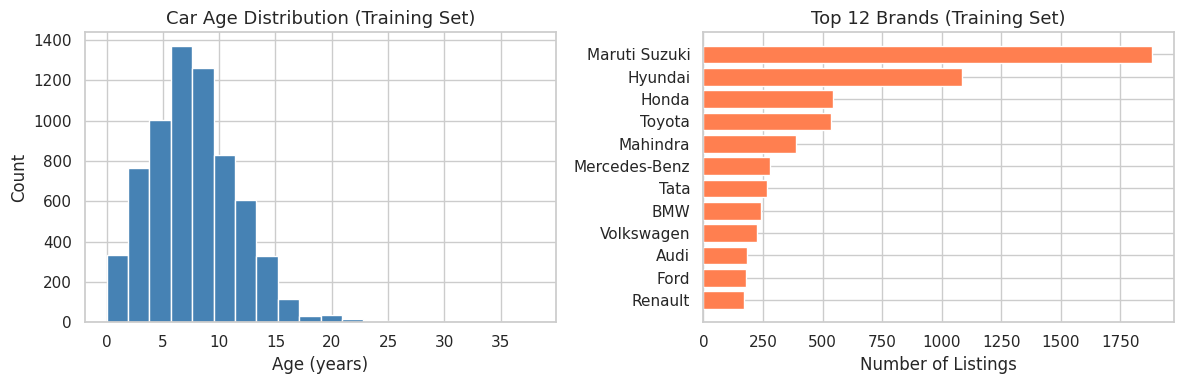

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of Age
axes[0].hist(train['Age'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Car Age Distribution (Training Set)', fontsize=13)
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')

# Brand frequency
brand_counts = train['Brand'].value_counts().head(12)
axes[1].barh(brand_counts.index[::-1], brand_counts.values[::-1], color='coral')
axes[1].set_title('Top 12 Brands (Training Set)', fontsize=13)
axes[1].set_xlabel('Number of Listings')

plt.tight_layout()
plt.show()

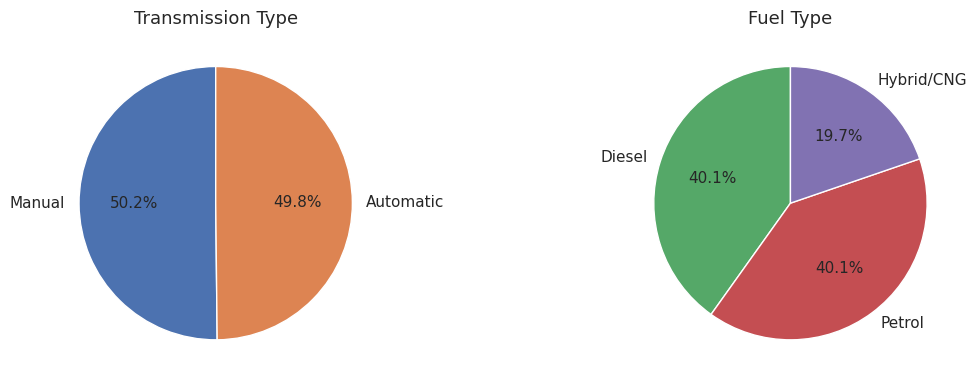

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Transmission
train['Transmission'].value_counts().plot.pie(
    ax=axes[0], autopct='%1.1f%%', startangle=90,
    colors=['#4C72B0', '#DD8452'], textprops={'fontsize': 11})
axes[0].set_title('Transmission Type', fontsize=13)
axes[0].set_ylabel('')

# Fuel Type
train['FuelType'].value_counts().plot.pie(
    ax=axes[1], autopct='%1.1f%%', startangle=90,
    colors=['#55A868', '#C44E52', '#8172B2'], textprops={'fontsize': 11})
axes[1].set_title('Fuel Type', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [11]:
# Owner type distribution
owner_counts = train['Owner'].value_counts()
print('Owner breakdown:')
print(owner_counts.to_frame().rename(columns={'count': 'Count'}))

Owner breakdown:
        Count
Owner        
first    3406
second   3301


<a id='4'></a>
## 4. Data Cleaning Steps — Before & After

Each sub-section shows the **BEFORE state**, applies a fix, then shows the **AFTER state**.

### 4a. Parse `kmDriven` — String → Numeric

**Problem:** Values like `'98,000 km'` and `'190000.0 km'` are stored as strings.  
**Fix:** Strip the `' km'` suffix and commas, then cast to `float`.

In [12]:
# BEFORE
print('BEFORE — dtype:', train['kmDriven'].dtype)
print('Sample values  :', train['kmDriven'].dropna().head(5).tolist())

BEFORE — dtype: object
Sample values  : ['16000.0 km', '47,600 km', '80,000 km', '96,000 km', '160,000 km']


In [13]:
# FIX: parse kmDriven
train['kmDriven'] = (
    train['kmDriven']
    .str.replace(' km', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# AFTER
print('AFTER — dtype:', train['kmDriven'].dtype)
print('Sample values :', train['kmDriven'].dropna().head(5).tolist())
print()
print(train['kmDriven'].describe())

AFTER — dtype: float64
Sample values : [16000.0, 47600.0, 80000.0, 96000.0, 160000.0]

count     6674.00
mean     71215.27
std      59487.67
min          0.00
25%      43074.25
50%      65000.00
75%      86000.00
max     980002.00
Name: kmDriven, dtype: float64


### 4b. Parse `AskPrice` — String → Numeric

**Problem:** Values like `'₹ 1,95,000'` contain the Rupee symbol and commas.  
**Fix:** Strip the symbol and commas, cast to `float`.

In [14]:
# BEFORE
print('BEFORE — dtype:', train['AskPrice'].dtype)
print('Sample values  :', train['AskPrice'].head(5).tolist())

BEFORE — dtype: object
Sample values  : ['₹ 4,20,000', '₹ 4,99,000', '₹ 5,85,000', '₹ 7,50,000', '₹ 2,60,000']


In [15]:
# FIX: parse AskPrice
train['AskPrice'] = (
    train['AskPrice']
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)

# AFTER
print('AFTER — dtype:', train['AskPrice'].dtype)
print('Sample values :', train['AskPrice'].head(5).tolist())
print()
print(train['AskPrice'].describe())

AFTER — dtype: float64
Sample values : [420000.0, 499000.0, 585000.0, 750000.0, 260000.0]

count       6707.00
mean     1069427.24
std      1673523.35
min        15000.00
25%       365000.00
50%       600000.00
75%      1128000.00
max     42500000.00
Name: AskPrice, dtype: float64


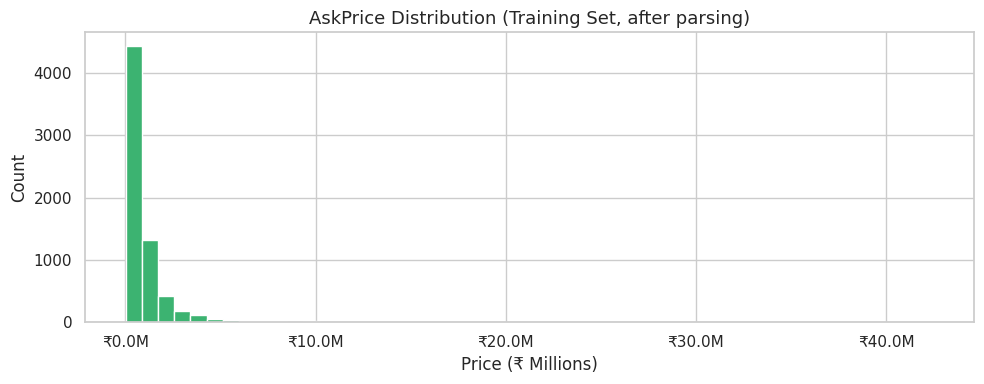

In [16]:
# Visualize price distribution after parsing
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train['AskPrice'] / 1e6, bins=50, color='mediumseagreen', edgecolor='white')
ax.set_title('AskPrice Distribution (Training Set, after parsing)', fontsize=13)
ax.set_xlabel('Price (₹ Millions)')
ax.set_ylabel('Count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.1f}M'))
plt.tight_layout()
plt.show()

### 4c. Handle Missing Values in `kmDriven`

**Problem:** 47 rows (~0.5%) have a null `kmDriven`.  
**Fix:** Impute with the **median** (robust to outliers).

In [17]:
# BEFORE
print('BEFORE — null count:', train['kmDriven'].isnull().sum())

BEFORE — null count: 33


In [18]:
# FIX: median imputation (fit on training data ONLY)
km_median = train['kmDriven'].median()
train['kmDriven'] = train['kmDriven'].fillna(km_median)

# AFTER
print(f'AFTER  — null count: {train["kmDriven"].isnull().sum()}')
print(f'Imputed value (median): {km_median:,.0f} km')

AFTER  — null count: 0
Imputed value (median): 65,000 km


### 4d. Remove Duplicate Rows

**Problem:** 724 duplicate rows exist in the raw dataset.  
**Fix:** Drop exact duplicates, keeping the first occurrence.

In [19]:
print(f'BEFORE — rows: {len(train):,}  |  duplicates: {train.duplicated().sum()}')

train = train.drop_duplicates()

print(f'AFTER  — rows: {len(train):,}  |  duplicates: {train.duplicated().sum()}')

BEFORE — rows: 6,707  |  duplicates: 399
AFTER  — rows: 6,308  |  duplicates: 0


### 4e. Drop Low-Utility Columns

| Column | Reason for Dropping |
|---|---|
| `AdditionInfo` | Free-text with inconsistent content; requires NLP and adds noise |
| `PostedDate` | Listing recency is not a property of the car; not predictive of price |
| `Year` | Redundant — `Age = current_year − Year`; keeping both causes multicollinearity |
| `model` | Too many unique values (hundreds); would explode one-hot encoding |


In [20]:
# BEFORE
print('BEFORE — columns:', train.columns.tolist())
print(f'          shape  : {train.shape}')

BEFORE — columns: ['Brand', 'model', 'Year', 'Age', 'kmDriven', 'Transmission', 'Owner', 'FuelType', 'PostedDate', 'AdditionInfo', 'AskPrice']
          shape  : (6308, 11)


In [21]:
# FIX: drop low-utility columns
cols_to_drop = ['AdditionInfo', 'PostedDate', 'Year', 'model']
train = train.drop(columns=cols_to_drop)

# AFTER
print('AFTER — columns:', train.columns.tolist())
print(f'         shape  : {train.shape}')

AFTER — columns: ['Brand', 'Age', 'kmDriven', 'Transmission', 'Owner', 'FuelType', 'AskPrice']
         shape  : (6308, 7)


### 4f. Filter Rare Brands

**Problem:** 39 unique brands exist, but many have very few listings  
(e.g., `Aston Martin`, `Rolls-Royce`, `Maserati` < 5 rows each).  
Rare brands make one-hot encoding noisy.  
**Fix:** Keep only the **top 16 brands** (by listing count); drop rows with rare brands.

In [22]:
# BEFORE — brand distribution
brand_dist = train['Brand'].value_counts()
print('BEFORE — unique brands:', train['Brand'].nunique())
print()
print('Full brand distribution:')
print(brand_dist.to_string())

BEFORE — unique brands: 39

Full brand distribution:
Brand
Maruti Suzuki    1811
Hyundai          1038
Toyota            511
Honda             508
Mahindra          379
Tata              258
Mercedes-Benz     255
Volkswagen        200
BMW               189
Ford              169
Renault           161
Audi              147
Skoda             122
Kia               105
Chevrolet          61
MG                 59
Nissan             53
Land Rover         49
Jeep               47
Volvo              34
Mini               26
Jaguar             21
Fiat               19
Datsun             18
Porsche            15
Mitsubishi         13
Lexus              12
Isuzu               7
Force               6
Ambassador          3
Bajaj               2
Rolls-Royce         2
Opel                2
ICML                1
Ashok               1
Aston Martin        1
Maserati            1
Bentley             1
Ssangyong           1


In [23]:
# FIX: keep only top 16 brands
TOP_N = 16
top_brands = train['Brand'].value_counts().head(TOP_N).index.tolist()
print(f'Keeping {TOP_N} brands:', top_brands)

rows_before = len(train)
train = train[train['Brand'].isin(top_brands)].copy()
rows_after = len(train)

print(f'\nRows before: {rows_before:,}  →  after: {rows_after:,}  (dropped {rows_before - rows_after} rare-brand rows)')
print(f'AFTER  — unique brands: {train["Brand"].nunique()}')

Keeping 16 brands: ['Maruti Suzuki', 'Hyundai', 'Toyota', 'Honda', 'Mahindra', 'Tata', 'Mercedes-Benz', 'Volkswagen', 'BMW', 'Ford', 'Renault', 'Audi', 'Skoda', 'Kia', 'Chevrolet', 'MG']

Rows before: 6,308  →  after: 5,973  (dropped 335 rare-brand rows)
AFTER  — unique brands: 16


### 4g. Encoding — One-Hot Encode Categorical Columns

ML algorithms need numbers, not text.  
**Columns encoded:** `Brand`, `Transmission`, `Owner`, `FuelType`  
We use `pd.get_dummies` with `drop_first=False` so all categories are explicit.

In [24]:
# BEFORE
cat_cols = ['Brand', 'Transmission', 'Owner', 'FuelType']
print('BEFORE — categorical columns:')
print(train[cat_cols].head(4))

BEFORE — categorical columns:
         Brand Transmission   Owner FuelType
8692   Renault    Automatic   first   Petrol
981    Hyundai    Automatic   first   Petrol
9544     Honda    Automatic  second   Petrol
1407  Mahindra       Manual   first   Diesel


In [25]:
# FIX: one-hot encode
train = pd.get_dummies(train, columns=cat_cols, dtype=int)

# AFTER
new_cols = [c for c in train.columns if any(c.startswith(p + '_') for p in cat_cols)]
print(f'AFTER — {len(new_cols)} new binary columns created:')
print(new_cols)
print()
print('Sample of encoded columns:')
train[new_cols[:6]].head(4)

AFTER — 23 new binary columns created:
['Brand_Audi', 'Brand_BMW', 'Brand_Chevrolet', 'Brand_Ford', 'Brand_Honda', 'Brand_Hyundai', 'Brand_Kia', 'Brand_MG', 'Brand_Mahindra', 'Brand_Maruti Suzuki', 'Brand_Mercedes-Benz', 'Brand_Renault', 'Brand_Skoda', 'Brand_Tata', 'Brand_Toyota', 'Brand_Volkswagen', 'Transmission_Automatic', 'Transmission_Manual', 'Owner_first', 'Owner_second', 'FuelType_Diesel', 'FuelType_Hybrid/CNG', 'FuelType_Petrol']

Sample of encoded columns:


,Brand_Audi,Brand_BMW,Brand_Chevrolet,Brand_Ford,Brand_Honda,Brand_Hyundai
8692,0,0,0,0,0,0
981,0,0,0,0,0,1
9544,0,0,0,0,1,0
1407,0,0,0,0,0,0


### 4h. Scaling — Standardize Numeric Columns

**Problem:** `kmDriven` ranges 0–980,000 while `Age` ranges 0–38.  
Large-scale differences bias distance-based and gradient-based ML models.  
**Fix:** Z-score standardization: mean=0, std=1  

> **Note:** The scaler is fitted here for demonstration and visualization purposes.  
> The cleaned CSV is saved with **real, unscaled values** so it stays human-readable.  
> When training the model, load the CSV and apply `scaler.transform()` at that point.


In [26]:
# BEFORE
num_cols = ['kmDriven', 'Age', 'AskPrice']
print('BEFORE — numeric column stats:')
train[num_cols].describe()

BEFORE — numeric column stats:


,kmDriven,Age,AskPrice
count,5973.00,5973.00,5973.00
mean,71831.82,7.67,951397.93
std,58851.58,4.12,1338843.40
min,0.00,0.00,15000.00
25%,44500.00,5.00,350000.00
50%,65563.00,7.00,580000.00
75%,86530.00,10.00,1021000.00
max,980002.00,38.00,24900000.00


In [27]:
# FIX: fit StandardScaler on training data (for visualization only)
# The CSV will be saved BEFORE this step so real values are preserved
num_cols = ['kmDriven', 'Age', 'AskPrice']
scaler = StandardScaler()
train_scaled = train.copy()
train_scaled[num_cols] = scaler.fit_transform(train[num_cols])

print('AFTER — numeric column stats (standardized, for reference):')
train_scaled[num_cols].describe()


AFTER — numeric column stats (standardized):


,kmDriven,Age,AskPrice
count,5973.00,5973.00,5973.00
mean,-0.00,-0.00,0.00
std,1.00,1.00,1.00
min,-1.22,-1.86,-0.70
25%,-0.46,-0.65,-0.45
50%,-0.11,-0.16,-0.28
75%,0.25,0.57,0.05
max,15.43,7.35,17.89


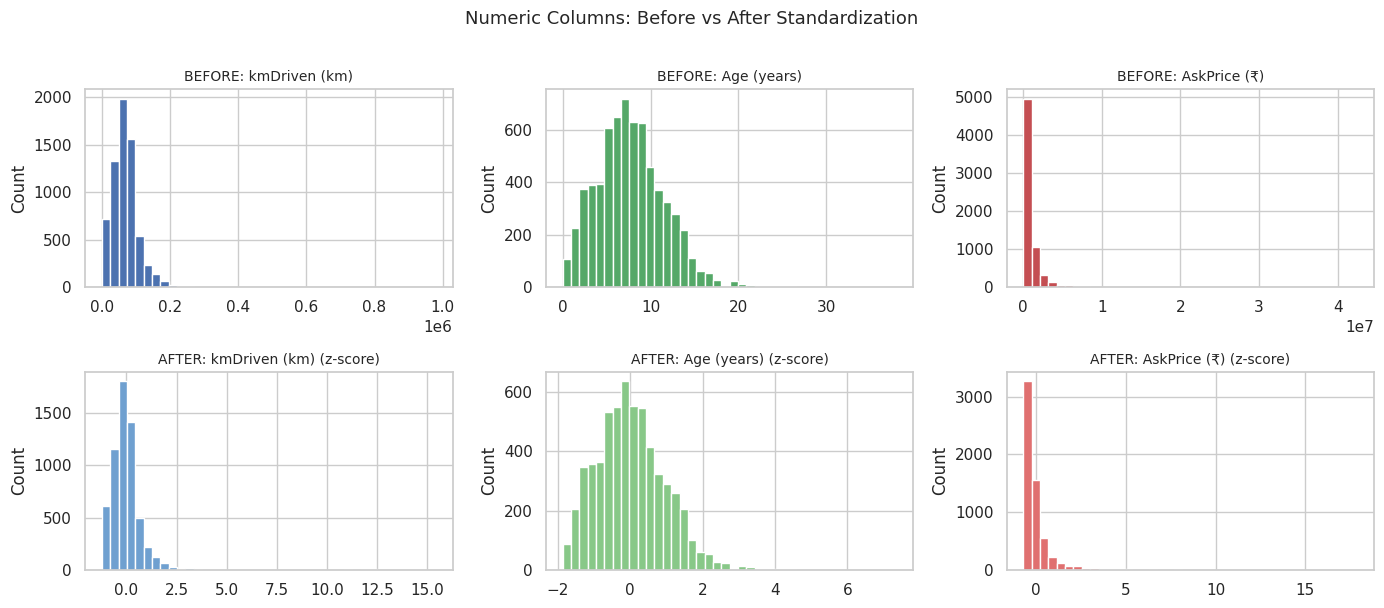

In [28]:
# Visualize the effect of scaling
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
fig.suptitle('Numeric Columns: Before vs After Standardization', fontsize=13, y=1.01)

# Re-load original for comparison
_orig = pd.read_csv('used_car_dataset.csv')
_orig_train, _ = train_test_split(_orig, test_size=0.30, random_state=42)

# Parse originals for plotting
_orig_km = _orig_train['kmDriven'].str.replace(' km','',regex=False).str.replace(',','',regex=False).astype(float)
_orig_price = _orig_train['AskPrice'].str.replace('₹','',regex=False).str.replace(',','',regex=False).str.strip().astype(float)
_orig_age = _orig_train['Age']

before_data = [_orig_km, _orig_age, _orig_price]
after_data  = [train_scaled['kmDriven'], train_scaled['Age'], train_scaled['AskPrice']]
labels = ['kmDriven (km)', 'Age (years)', 'AskPrice (₹)']
colors_b = ['#4C72B0', '#55A868', '#C44E52']
colors_a = ['#6FA0D0', '#88C888', '#E07070']

for i, (b, a, lbl, cb, ca) in enumerate(zip(before_data, after_data, labels, colors_b, colors_a)):
    axes[0, i].hist(b.dropna(), bins=40, color=cb, edgecolor='white')
    axes[0, i].set_title(f'BEFORE: {lbl}', fontsize=10)
    axes[0, i].set_ylabel('Count')

    axes[1, i].hist(a.dropna(), bins=40, color=ca, edgecolor='white')
    axes[1, i].set_title(f'AFTER: {lbl} (z-score)', fontsize=10)
    axes[1, i].set_ylabel('Count')

plt.tight_layout()
plt.show()


<a id='5'></a>
## 5. Before vs After Summary

Full side-by-side comparison of the raw dataset and the cleaned training set.

In [29]:
# Side-by-side shape
print('=== SHAPE ===')
print(f'  Raw dataset  : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'  Cleaned train: {train.shape[0]:,} rows × {train.shape[1]} columns')
print()

# Null comparison
print('=== NULL VALUES ===')
print(f'  Raw   nulls: {df_raw.isnull().sum().sum()}')
print(f'  Clean nulls: {train.isnull().sum().sum()}')
print()

# Duplicate comparison
print('=== DUPLICATES ===')
print(f'  Raw   duplicates: {df_raw.duplicated().sum()}')
print(f'  Clean duplicates: {train.duplicated().sum()}')
print()

# Column listing
print('=== COLUMNS (clean) ===')
for c in train.columns:
    print(f'  {c}: {train[c].dtype}')

=== SHAPE ===
  Raw dataset  : 9,582 rows × 11 columns
  Cleaned train: 5,973 rows × 26 columns

=== NULL VALUES ===
  Raw   nulls: 47
  Clean nulls: 0

=== DUPLICATES ===
  Raw   duplicates: 724
  Clean duplicates: 55

=== COLUMNS (clean) ===
  Age: float64
  kmDriven: float64
  AskPrice: float64
  Brand_Audi: int64
  Brand_BMW: int64
  Brand_Chevrolet: int64
  Brand_Ford: int64
  Brand_Honda: int64
  Brand_Hyundai: int64
  Brand_Kia: int64
  Brand_MG: int64
  Brand_Mahindra: int64
  Brand_Maruti Suzuki: int64
  Brand_Mercedes-Benz: int64
  Brand_Renault: int64
  Brand_Skoda: int64
  Brand_Tata: int64
  Brand_Toyota: int64
  Brand_Volkswagen: int64
  Transmission_Automatic: int64
  Transmission_Manual: int64
  Owner_first: int64
  Owner_second: int64
  FuelType_Diesel: int64
  FuelType_Hybrid/CNG: int64
  FuelType_Petrol: int64


In [30]:
# Visual summary: raw vs clean column overview
summary = pd.DataFrame({
    'Raw Dataset': {
        'Rows':            f'{len(df_raw):,}',
        'Columns':         str(len(df_raw.columns)),
        'Null cells':      str(int(df_raw.isnull().sum().sum())),
        'Duplicate rows':  str(int(df_raw.duplicated().sum())),
        'Numeric cols':    str(int(df_raw.select_dtypes(include='number').shape[1])),
        'String cols':     str(int(df_raw.select_dtypes(include='object').shape[1])),
        'AskPrice dtype':  str(df_raw['AskPrice'].dtype),
        'kmDriven dtype':  str(df_raw['kmDriven'].dtype),
    },
    'Cleaned Train Set': {
        'Rows':            f'{len(train):,}',
        'Columns':         str(len(train.columns)),
        'Null cells':      str(int(train.isnull().sum().sum())),
        'Duplicate rows':  str(int(train.duplicated().sum())),
        'Numeric cols':    str(int(train.select_dtypes(include='number').shape[1])),
        'String cols':     str(int(train.select_dtypes(include='object').shape[1])),
        'AskPrice dtype':  str(train['AskPrice'].dtype),
        'kmDriven dtype':  str(train['kmDriven'].dtype),
    }
})

print('=== BEFORE vs AFTER COMPARISON ===')
summary

=== BEFORE vs AFTER COMPARISON ===


,Raw Dataset,Cleaned Train Set
Rows,"9,582","5,973"
Columns,11,26
Null cells,47,0
Duplicate rows,724,55
Numeric cols,2,26
String cols,9,0
AskPrice dtype,object,float64
kmDriven dtype,object,float64


In [31]:
# Final cleaned training set preview
print('Final cleaned training set (first 5 rows):')
train.head()

Final cleaned training set (first 5 rows):


,Age,kmDriven,AskPrice,Brand_Audi,Brand_BMW,Brand_Chevrolet,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Kia,...,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Transmission_Automatic,Transmission_Manual,Owner_first,Owner_second,FuelType_Diesel,FuelType_Hybrid/CNG,FuelType_Petrol
8692,-0.65,-0.95,-0.40,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,1
981,-0.16,-0.41,-0.34,0,0,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
9544,0.32,0.14,-0.27,0,0,0,0,1,0,0,...,0,0,0,1,0,0,1,0,0,1
1407,0.08,0.41,-0.15,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,1,0,0
7795,-1.62,-1.07,0.37,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,1


<a id='6'></a>
## 6. Save the Cleaned Dataset

We save the cleaned training set with **real, unscaled values** so the CSV is human-readable in Excel.  
Scaling will be applied at model-training time using the `scaler` fitted in Step 4h.


In [32]:
# Save with REAL values (unscaled) — readable in Excel
output_path = 'final_cleaned_dataset_readable.csv'
train.to_csv(output_path, index=False)

print(f'Cleaned training set saved to: {output_path}')
print(f'Shape: {train.shape[0]:,} rows × {train.shape[1]} columns')
print()
print('Sample AskPrice values (real ₹):', train['AskPrice'].head(3).tolist())
print('Sample kmDriven values (real km):', train['kmDriven'].head(3).tolist())
print()
print('To apply scaling at model-training time:')
print('  X_train = scaler.transform(train[["kmDriven", "Age", "AskPrice"]])')
print('  X_test  = scaler.transform(test[["kmDriven",  "Age", "AskPrice"]])')


Cleaned training set saved to: final_cleaned_dataset.csv
Shape: 5,973 rows × 26 columns


In [ ]:
# ── Ready-to-use snippet: load CSV and apply scaling for model training ──
# Run this when you are ready to train your model

df_model = pd.read_csv('final_cleaned_dataset_readable.csv')

num_cols = ['kmDriven', 'Age', 'AskPrice']

# Separate features and target
X = df_model.drop(columns=['AskPrice'])
y = df_model['AskPrice']

# Apply scaler fitted in Step 4h
X[['kmDriven', 'Age']] = scaler.transform(X[['kmDriven', 'Age']])

print(f'X shape: {X.shape}  |  y shape: {y.shape}')
print('Ready for model training!')


<a id='7'></a>
## 7. ML Problem Discussion

### What ML problem does this dataset solve?

**Task:** **Supervised Regression** — predicting the continuous numeric target `AskPrice`.

### Features (X) → Target (y)

| Feature | Type | Notes |
|---|---|---|
| `kmDriven` | Numeric (scaled) | Higher mileage → lower price |
| `Age` | Numeric (scaled) | Older cars → lower price |
| `Brand_*` | Binary (one-hot) | Brand prestige affects price |
| `Transmission_*` | Binary (one-hot) | Automatic often priced higher |
| `Owner_*` | Binary (one-hot) | First-owner cars command premium |
| `FuelType_*` | Binary (one-hot) | Diesel vs Petrol vs CNG |
| **`AskPrice`** | **Numeric (target)** | **What we predict** |

### Recommended Models

1. **Linear Regression** — baseline; interpretable coefficients
2. **Random Forest Regressor** — handles nonlinear relationships; feature importance
3. **Gradient Boosting (XGBoost / LightGBM)** — typically best accuracy for tabular data

### Evaluation Metrics

- **MAE** (Mean Absolute Error) — average ₹ error; easy to interpret
- **RMSE** (Root Mean Squared Error) — penalizes large errors more
- **R²** (Coefficient of Determination) — percentage of variance explained

### Why this problem matters

Accurate price prediction helps:  
- **Buyers** avoid overpaying  
- **Sellers** price competitively  
- **Dealerships** value inventory automatically at scale
